In [14]:
from pathlib import Path
import json
from nltk.tokenize import sent_tokenize
from sentence_transformers import CrossEncoder, SentenceTransformer
from bert_score import score

# scikit-learn imports
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from torch.nn.modules import transformer

nli_model = CrossEncoder('cross-encoder/nli-deberta-v3-large')
transformer_model = SentenceTransformer("all-mpnet-base-v2")

vectorizer = TfidfVectorizer()


In [27]:
import sys, numpy as np, json
from pathlib import Path
sys.path.insert(0, "..")
from nltk.tokenize import sent_tokenize
from constants import GROUND_TRUTH_LIBRARY

GT  = " ".join(GROUND_TRUTH_LIBRARY.get("ground_truth_1").get("snippets", []))
GT_summary = GROUND_TRUTH_LIBRARY.get("ground_truth_1").get("summary", "")
GT_facts = GROUND_TRUTH_LIBRARY.get("ground_truth_1").get("facts", "")

def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum()
EXPERIMENT_DIR = '/Users/nyuad/Desktop/capstone/experiments/constant_ratio_pool_social/run_0007/experiment.json'
experiment_data = json.loads(Path(EXPERIMENT_DIR).read_text())
print(GT)
print(GT_summary)
print(GT_facts)


Students line up outside the university gym before the career fair opens. Event staff scan registrations and hand out lanyards at the entrance. Dozens of booths with colorful banners circle the polished floor. Tech companies display demo screens showing their latest apps. Consulting firms stack glossy case study booklets on high tables. Healthcare providers showcase community outreach photos. Students clutch resumes inside branded folders. Career counselors remind attendees to maintain eye contact. Alumni volunteers share quick pep talks near the coffee station. A welcome announcement outlines the fair schedule over the PA system.
Hundreds of students crowd the university gym for the career fair, where recruiters from multiple industries trade quick conversations for resumes. Counselors and alumni give guidance while announcements keep the schedule moving, sustaining an energetic hunt for internships and entry-level roles.
The university gym hosts the annual career fair filled with com

In [137]:
test_pairs = [
    ("A man is eating pizza", "A man eats something"),           # clear entailment
    ("A cat is sleeping", "A dog is running"),                   # neutral
    ("It is raining outside", "The weather is dry and sunny"),   # contradiction
]

raw = nli_model.predict(test_pairs)
probs = nli_model.predict(test_pairs, apply_softmax=True)

expected = ["entailment", "neutral", "contradiction"]
for i, (pair, raw_scores, prob_scores) in enumerate(zip(test_pairs, raw, probs)):
    print(f"\nPremise:    {pair[0]}")
    print(f"Hypothesis: {pair[1]}")
    print(f"Expected:   {expected[i]}")
    print(f"  Raw logits:      {raw_scores}")
    print(f"  apply_softmax:   {prob_scores}")
    print(f"  Argmax: index={raw_scores.argmax()} → LABELS[{raw_scores.argmax()}] = {LABELS[raw_scores.argmax()]}")


Premise:    A man is eating pizza
Hypothesis: A man eats something
Expected:   entailment
  Raw logits:      [-5.2488985   5.0883465  -0.26309612]
  apply_softmax:   [3.224952e-05 9.952490e-01 4.718779e-03]
  Argmax: index=1 → LABELS[1] = entailment

Premise:    A cat is sleeping
Hypothesis: A dog is running
Expected:   neutral
  Raw logits:      [ 6.806318  -5.978935  -3.6804423]
  apply_softmax:   [9.9996924e-01 2.8017025e-06 2.7902595e-05]
  Argmax: index=0 → LABELS[0] = contradiction

Premise:    It is raining outside
Hypothesis: The weather is dry and sunny
Expected:   contradiction
  Raw logits:      [ 6.9709444 -5.9191737 -3.9146526]
  apply_softmax:   [9.9997878e-01 2.5228060e-06 1.8725612e-05]
  Argmax: index=0 → LABELS[0] = contradiction


In [28]:
import re
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
LABELS = ["contradiction", "entailment", "neutral"]
LABEL_SCORES = {"contradiction": -1, "entailment": 1, "neutral": 0}

def decompose_into_sentences(text):
    sentences = re.split(r'[.!?]', text.strip())
    return [s.strip() for s in sentences if len(s.strip()) > 10]

gt_claims = sent_tokenize(GT_summary)
print(f"gt_claims: {gt_claims}, {len(gt_claims)}")


def evaluate_coverage(gt_claims: list[str], agent_summary: str):
    agent_sentences = sent_tokenize(agent_summary)
    print(f"agent_sentences: {agent_sentences}, {len(agent_sentences)}")
    print(f"gt_claims: {gt_claims}, {len(gt_claims)}")
    n_agents = len(agent_sentences)
    n_claims = len(gt_claims)

    coverage_pairs = [
        (sentence, claim)
        for claim in gt_claims
        for sentence in agent_sentences
    ]

    probs = nli_model.predict(coverage_pairs, apply_softmax=True)

    coverage_matrix = np.zeros((n_agents, n_claims))

    for idx, (j, i) in enumerate((j, i) for i in range(n_claims) for j in range(n_agents)):
        predicted_label = LABELS[probs[idx].argmax()]
        coverage_matrix[j, i] = LABEL_SCORES[predicted_label]

    best_per_claim = coverage_matrix.max(axis=0)
    total_score = best_per_claim.sum()
    max_possible = n_claims
    min_possible = -n_claims

    print(f"\n--- Coverage Summary ---")
    for ci, claim in enumerate(gt_claims):
        best_idx = coverage_matrix[:, ci].argmax()
        best_val = coverage_matrix[best_idx, ci]
        label = {1: "entailment", 0: "neutral", -1: "contradiction"}[best_val]
        print(f"  Claim {ci}: best={best_val:+.0f} ({label}) from agent sent {best_idx}")
    print(f"  Total score: {total_score:+.0f} / {max_possible} (range [{min_possible}, {max_possible}])")
    print(f"  Entailed claims: {int((best_per_claim == 1).sum())} / {n_claims}")

    return coverage_matrix

def compute_cosine_similarity(gt_claims: list[str], agent_summary: str):
    
    
    agent_sentences = sent_tokenize(agent_summary)
    print(f"agent_sentences: {agent_sentences}, {len(agent_sentences)}")
    print(f"gt_claims: {gt_claims}, {len(gt_claims)}")
    cosine_matrix = np.zeros((len(gt_claims), len(agent_sentences)))
    for i, claim in enumerate(gt_claims):
        for j, agent_sentence in enumerate(agent_sentences):
        # vectorize both
            documents = [agent_sentence, claim]
            tfidf_matrix = vectorizer.fit_transform(documents)
            similarity_score = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])
            cosine_matrix[i, j] = similarity_score[0][0]

    return cosine_matrix




def print_matrix(matrix, row_labels=None, col_labels=None, title="", max_label_len=50):
    
    mat = np.array(matrix)
    n_rows, n_cols = mat.shape

    if row_labels is None:
        row_labels = [f"S{i}" for i in range(n_rows)]
    if col_labels is None:
        col_labels = [f"F{j}" for j in range(n_cols)]

    def _trunc(s, n=max_label_len):
        s = s.strip()
        return s if len(s) <= n else s[:n].rsplit(" ", 1)[0] + "…"

    row_labels = [_trunc(l) for l in row_labels]
    col_labels = [_trunc(l) for l in col_labels]

    cell_w = max(1.4, min(2.2, 20.0 / n_cols))
    cell_h = max(0.6, min(1.2, 14.0 / n_rows))
    fig_w = max(10, n_cols * cell_w + 4)
    fig_h = max(4, n_rows * cell_h + 3)

    fig, ax = plt.subplots(figsize=(fig_w, fig_h), facecolor="#0d1117")
    ax.set_facecolor("#0d1117")

    cmap = LinearSegmentedColormap.from_list(
        "blue_red", ["#1e3a5f", "#3b7dd8", "#f0f0f0", "#e8644a", "#c0392b"]
    )
    im = ax.imshow(mat, cmap=cmap, aspect="auto", vmin=-1, vmax=1)

    for i in range(n_rows):
        for j in range(n_cols):
            val = mat[i, j]
            color = "white" if val < 0.35 or val > 0.75 else "#1a1a2e"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=max(6, min(9, 100 // max(n_rows, n_cols))),
                    color=color, fontweight="bold")

    ax.set_xticks(range(n_cols))
    ax.set_xticklabels(col_labels, rotation=45, ha="right", fontsize=7, color="#c9d1d9")
    ax.set_yticks(range(n_rows))
    ax.set_yticklabels(row_labels, fontsize=7, color="#c9d1d9")

    if title:
        ax.set_title(title, fontsize=14, color="#ffffff", fontweight="bold", pad=12)

    cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.04)
    cbar.ax.tick_params(colors="#8b949e", labelsize=8)

    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.tight_layout()
    plt.show()






gt_claims: ['Hundreds of students crowd the university gym for the career fair, where recruiters from multiple industries trade quick conversations for resumes.', 'Counselors and alumni give guidance while announcements keep the schedule moving, sustaining an energetic hunt for internships and entry-level roles.'], 2


In [9]:
import pandas as pd

def show_pairs(matrix, agent_sentences, gt_claims, title="", top_n=None):
    """
    Flattens a (n_agents x n_claims) score matrix into a sorted DataFrame.
    Scores: +1 = entailment, 0 = neutral, -1 = contradiction.
    """
    rows = []
    n_agents, n_claims = matrix.shape
    label_map = {1: "entailment", 0: "neutral", -1: "contradiction"}
    for i in range(n_claims):
        for j in range(n_agents):
            val = int(matrix[j, i])
            rows.append({
                "agent_idx": j,
                "claim_idx": i,
                "agent_sentence": agent_sentences[j],
                "gt_claim": gt_claims[i],
                "score": val,
                "label": label_map[val],
            })

    df = pd.DataFrame(rows).sort_values("score", ascending=False).reset_index(drop=True)

    if top_n is not None:
        df = df.head(top_n)

    if title:
        print(f"\n{'='*60}\n{title}\n{'='*60}")

    def color_score(val):
        if val == 1:
            return "background-color: #2d6a4f; color: green"
        elif val == 0:
            return "background-color: #f4d35e; color: black"
        else:
            return "background-color: #e63946; color: white"

    return df.style.applymap(color_score, subset=["score"])



Agent 0
Last summary: Students clutch resumes inside branded folders, and alumni volunteers are sharing quick pep talks near the coffee station. Career counselors remind attendees to maintain eye contact, and a welcome announcement outlines the fair schedule over the PA system. Additionally, dozens of booths with colorful banners circle the polished floor, and at the entrance, event staff scan registrations and hand out lanyards. Before the career fair opens, students line up outside the university gym.

agent_sentences: ['Students clutch resumes inside branded folders, and alumni volunteers are sharing quick pep talks near the coffee station.', 'Career counselors remind attendees to maintain eye contact, and a welcome announcement outlines the fair schedule over the PA system.', 'Additionally, dozens of booths with colorful banners circle the polished floor, and at the entrance, event staff scan registrations and hand out lanyards.', 'Before the career fair opens, students line up ou

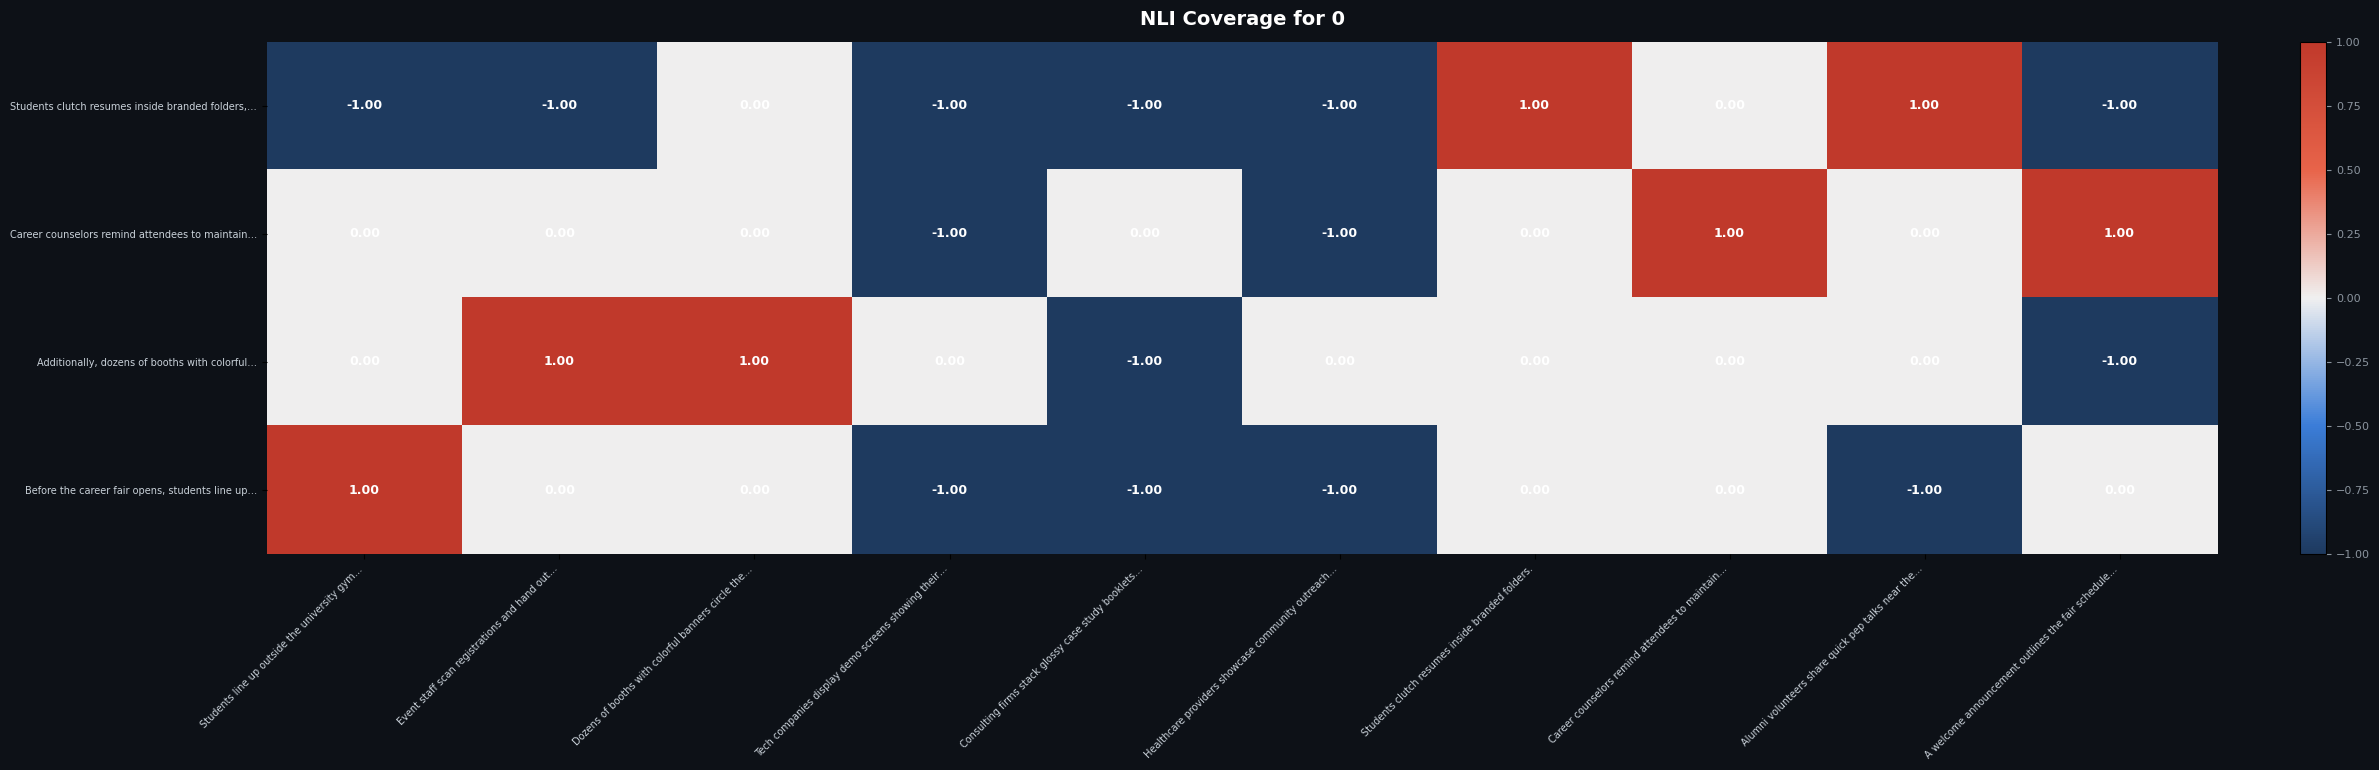

Claim probabilities:
contradiction: 0.0008
entailment: 0.9719
neutral: 0.0273
Predicted label for claim: entailment

Students line up outside the university gym before the career fair opens. Event staff scan registrations and hand out lanyards at the entrance. Dozens of booths with colorful banners circle the polished floor. Tech companies display demo screens showing their latest apps. Consulting firms stack glossy case study booklets on high tables. Healthcare providers showcase community outreach photos. Students clutch resumes inside branded folders. Career counselors remind attendees to maintain eye contact. Alumni volunteers share quick pep talks near the coffee station. A welcome announcement outlines the fair schedule over the PA system.
Students clutch resumes inside branded folders, and alumni volunteers are sharing quick pep talks near the coffee station. Career counselors remind attendees to maintain eye contact, and a welcome announcement outlines the fair schedule over th

In [29]:
agents_data = experiment_data['agents']

claims = sent_tokenize(GT) # the plain ground truth
summary_claims = sent_tokenize(GT_summary) # this is from the AI-generated summary at the start of the experiment
facts = sent_tokenize(GT_facts) # the facts generated by the AI


for agent_id, agent_data in agents_data.items():
    print(f"\n{'='*60}")
    print(f"Agent {agent_id}")
    print(f"{'='*60}")
    summary_data = agent_data['summaries']
    summaries = list(summary_data.values())
    last_summary = summaries[-1]
    print(f"Last summary: {last_summary}\n")
    agent_sentences = sent_tokenize(last_summary)

    claim_coverage_matrix = evaluate_coverage(claims, last_summary)
    # fact_coverage_matrix = evaluate_coverage(facts, last_summary)
    # summary_coverage_matrix = evaluate_coverage(summary_claims, last_summary)
    

    #print matrix for all 3 of them
    print_matrix(claim_coverage_matrix, row_labels=agent_sentences, col_labels=claims, title=f"NLI Coverage for {agent_id}")
    # print_matrix(fact_coverage_matrix, row_labels=agent_sentences, col_labels=facts, title=f"NLI Coverage for {agent_id}")
    # print_matrix(summary_coverage_matrix, row_labels=agent_sentences, col_labels=summary_claims, title=f"NLI Coverage for {agent_id}")
    

    #print raw score without matrix for all 3 of them
    claim_probs = nli_model.predict([(last_summary, GT)], apply_softmax=True)[0]
    print("Claim probabilities:")
    for label, prob in zip(LABELS, claim_probs):
        print(f"{label}: {prob:.4f}")

    print(f"Predicted label for claim: {LABELS[claim_probs.argmax()]}\n")
    print(GT)
    print(last_summary)

    # fact_probs = nli_model.predict([(last_summary, GT_facts)], apply_softmax=True)[0]
    # print("Fact probabilities:")
    # for label, prob in zip(LABELS, fact_probs):
    #     print(f"{label}: {prob:.4f}")
    # print(f"Predicted label for fact: {LABELS[fact_probs.argmax()]}\n")

    # summary_probs = nli_model.predict([(last_summary, GT_summary)], apply_softmax=True)[0]
    # print("Summary probabilities:")
    # for label, prob in zip(LABELS, summary_probs):
    #     print(f"{label}: {prob:.4f}")
    # print(f"Predicted label for summary: {LABELS[summary_probs.argmax()]}\n")

    

    break

Agent 0
Last summary: Dozens of booths with colorful banners circle the polished floor. Event staff scan registrations and hand out lanyards at the entrance. Students use tablets at kiosks to upload resumes to the fair database. Career counselors remind attendees to maintain eye contact. Consulting firms stack glossy case study booklets on high tables. Finance firms offer QR codes for immediate internship applications. Data science company showcases live dashboard of fair attendance. Camera crews from the university media team capture interviews. Whiteboard lists employers scheduling same-day interviews. Engineering society sponsors resume review table near the stage. Alumni panel discusses how to prepare for technical interviews. Startup founder invites students to a lunchtime pitch session. Recruiters distribute tote bags filled with branded notebooks and pens. Groups of friends mark target employers on the event map. Small groups analyze which recruiters seemed most enthusiastic. He

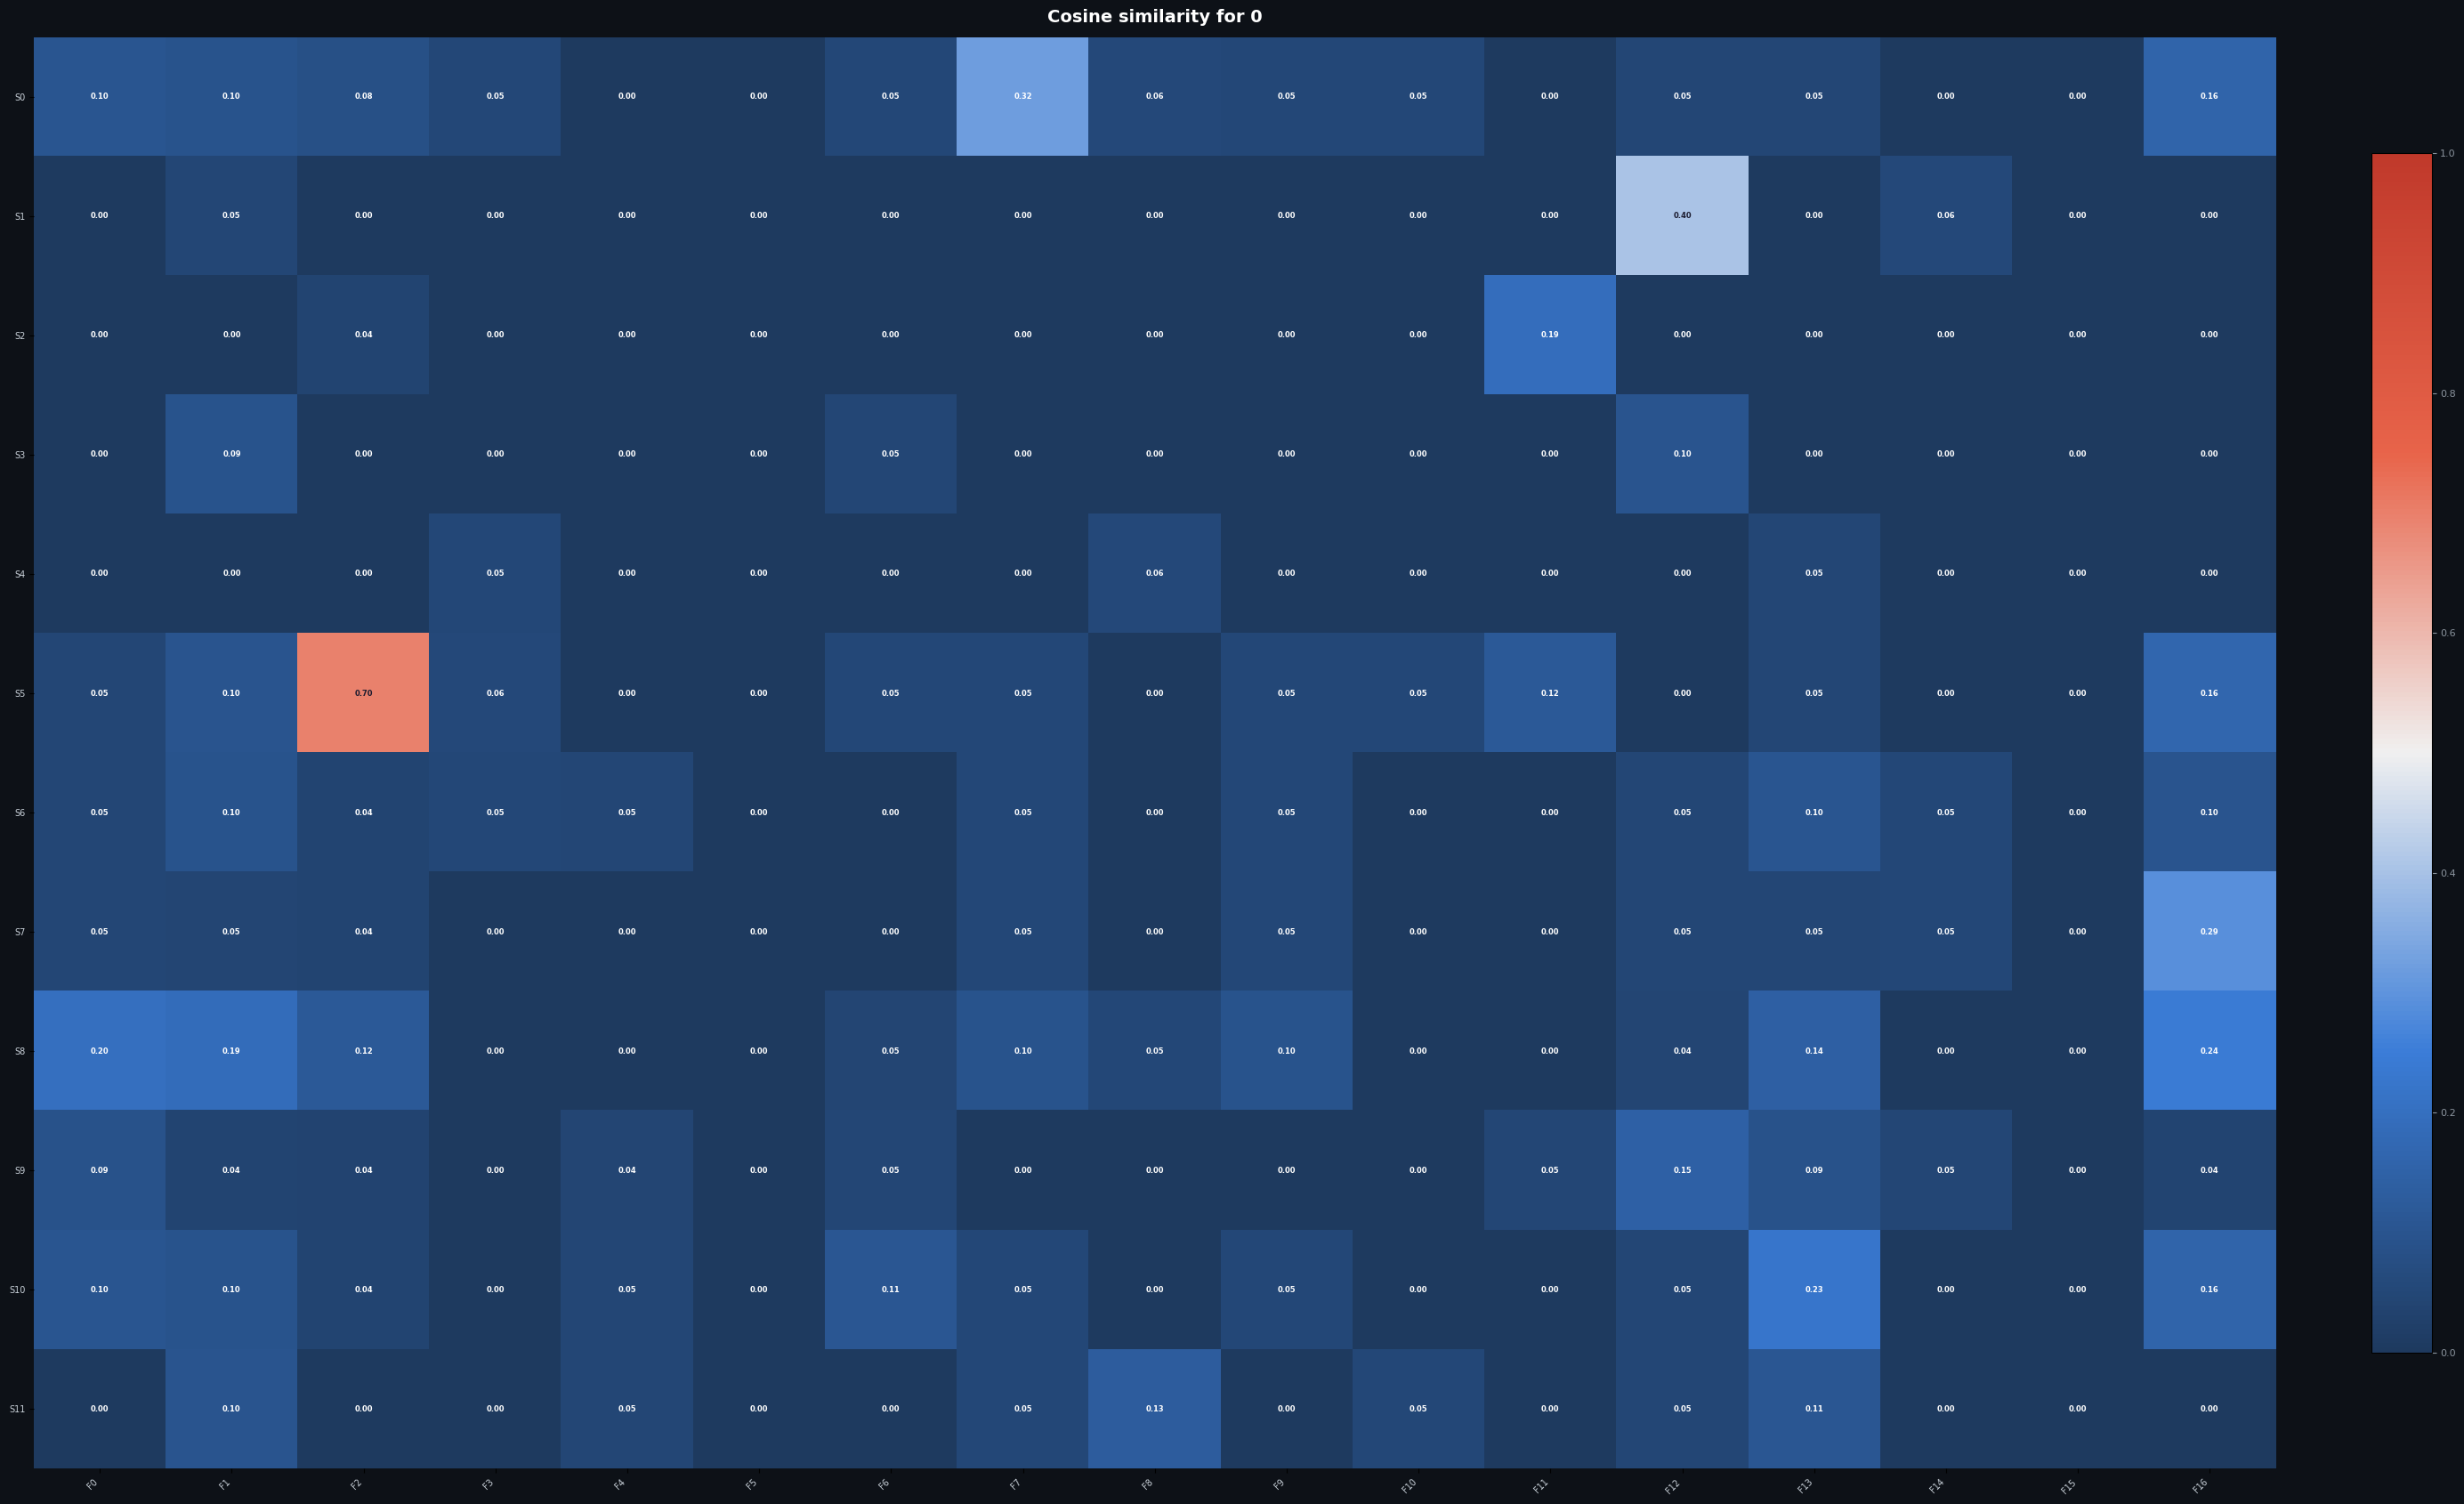

Agent 1
Last summary: Dozens of booths with colorful banners circle polished floor. Small groups analyze which recruiters seemed most enthusiastic. Career counselors remind attendees to maintain eye contact. Consulting firms stack glossy case-study booklets on high tables. Data science company showcases live dashboard of fair attendance. University media team camera crews capture interviews. Alumni panel discusses technical interview preparation. Human resources teams jot notes on tablets while students introduce themselves. Engineering society sponsors resume review table near stage. Event staff scan registrations, hand out lanyards at entrance. Groups of friends mark target employers on event map. Students use tablets at kiosks to upload resumes to fair database. Whiteboard lists employers scheduling same-day interviews. Interview sign-up sheets fill with names as day winds down. Recruiters remind students to follow up with personalized emails. Post-event survey link flashes on monit

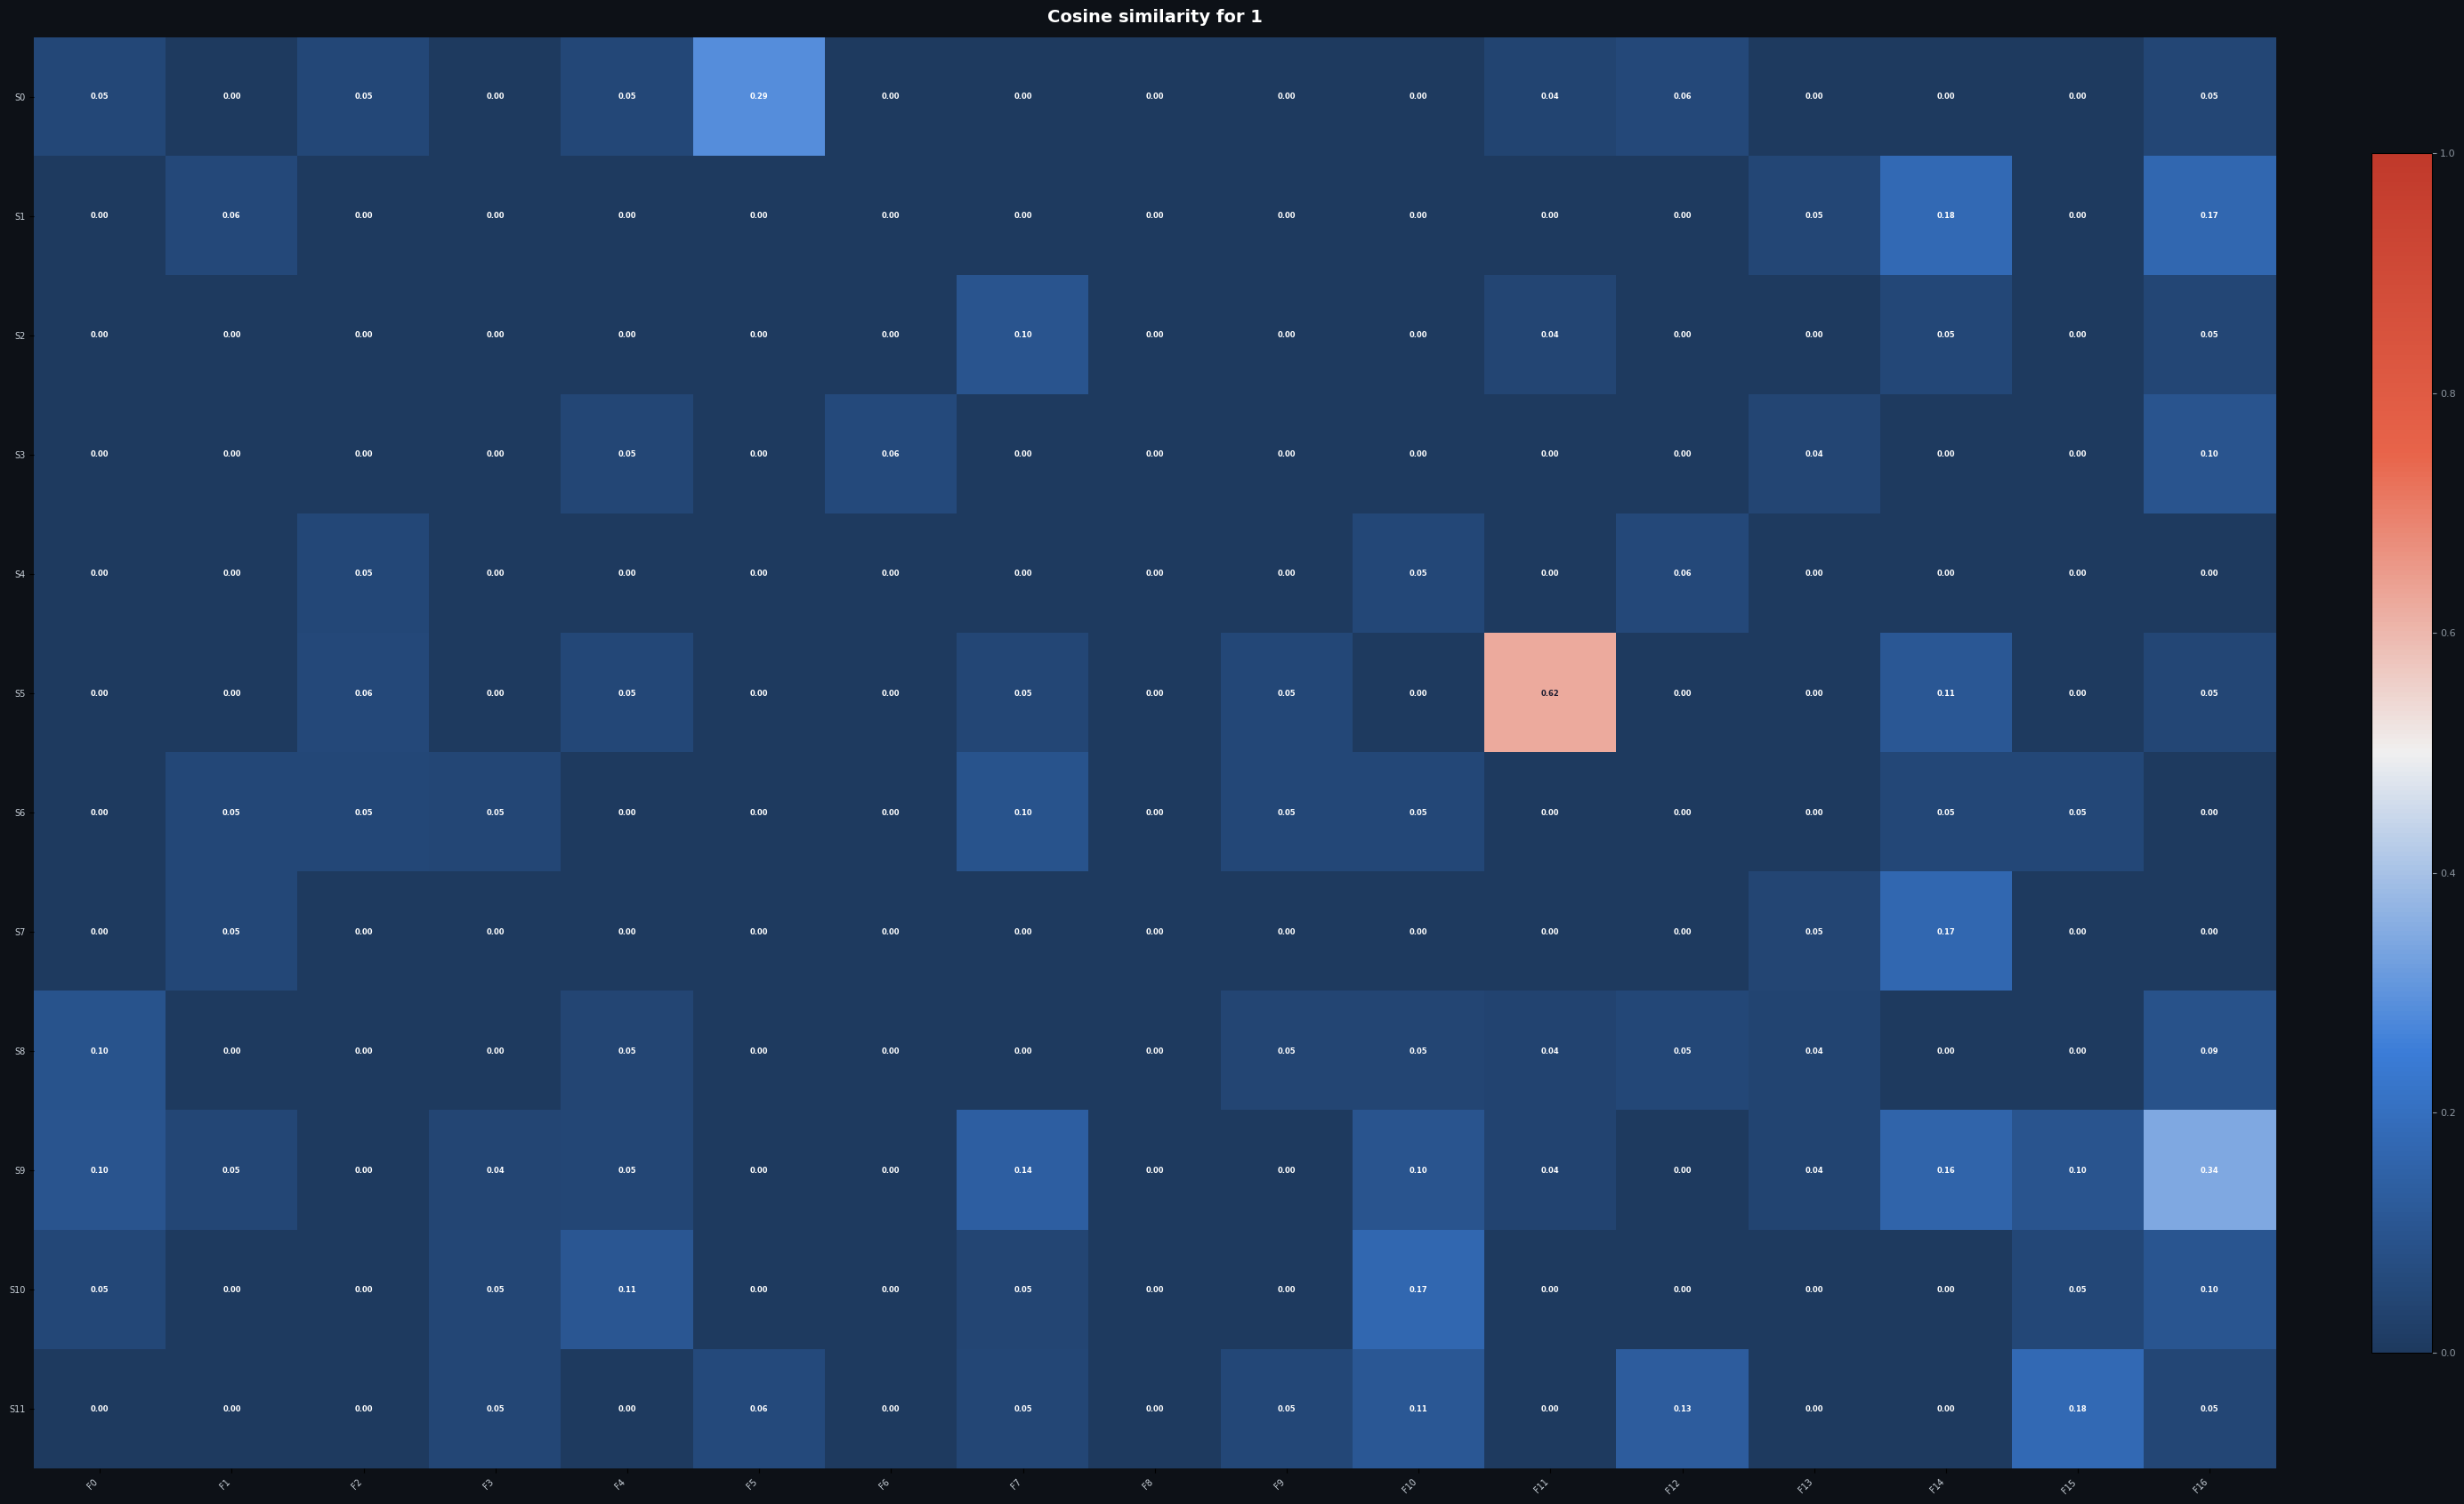

In [ ]:
agents_data = experiment_data['agents']

i = 0

for agent_id, agent_data in agents_data.items():
    print(f"Agent {agent_id}")
    summary_data = agent_data['summaries']
    summaries = list(summary_data.values())
    last_summary = summaries[-1]
    print(f"Last summary: {last_summary}")
    agent_sentences = sent_tokenize(last_summary)
    cosine_matrix = compute_cosine_similarity(gt_claims, last_summary)
    cosine_matrix is (n_claims x n_agents), transpose to (n_agents x n_claims) for show_pairs
    print_matrix(cosine_matrix, title=f"Cosine similarity for {agent_id}")
    display(show_pairs(cosine_matrix.T, agent_sentences, gt_claims, title=f"Cosine pairs — {agent_id}"))
    i += 1
    if i >= 2:
        break

In [120]:
print("GT: ", GT)
i = 0
for agent_id, agent_data in agents_data.items():
    print(f"Agent {agent_id}")
    summary_data = agent_data['summaries']
    summaries = list(summary_data.values())
    last_summary = summaries[-1]
    print(f"summary: {last_summary}")
    P, R, F1 = score(
    cands=[last_summary],
    refs=[GT],
    model_type="allenai/longformer-base-4096",  # supports up to 4096 tokens
    lang="en"
)
    print(f"P: {P}, R: {R}, F1: {F1}")

GT:  University media crews record interviews and highlights across the career fair floor. Recruiters distribute tote bags, notebooks, tech swag, and follow-up instructions. Startups schedule lunchtime pitch sessions while international students receive visa guidance. Whiteboards and dashboards track interview slots, attendance numbers, and recruiter availability. Nonprofits share mission-driven roles beside corporate employers, emphasizing varied career paths. Students upload resumes at digital kiosks tied to the fair database. The dean thanks recruiters while career center staff log metrics on laptops. Chimes announce the final hour as recruiters encourage personalized email follow-ups. Volunteers pack booths and collect leftover brochures at the end of the day. Students depart with stacks of business cards, survey links, and notes on responsive recruiters. Friends debrief on the quad, comparing impressions of company cultures and enthusiasm. Post-event planning focuses on scheduling

KeyboardInterrupt: 

In [ ]:
probs = nli_model.predict([('', '')], apply_softmax=True)[0]
label = LABELS[probs.argmax()]
print("GT_summary: ", GT_summary)
print("last_summary: ", last_summary) 
print(f"NLI vs GT summary → {label}  (contradiction={probs[0]:.3f}, entailment={probs[1]:.3f}, neutral={probs[2]:.3f})")